In [25]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

In [26]:
x_train = pd.read_csv("../data/x_train_final.csv")
x_test = pd.read_csv("../data/x_test_final.csv")

In [27]:
y_train = pd.read_csv("../data/y_train_final.csv")
y_train = y_train.drop(columns=["Unnamed: 0"])

In [28]:
x_train

,Unnamed: 0.1,Unnamed: 0,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
0,0,0,VBXNMF,KYF,2023-04-03,8,0.0,0.0,1.0,-3.0,-1.0,-2.0
1,1,1,VBXNMF,JLR,2023-04-03,9,0.0,0.0,0.0,1.0,0.0,1.0
2,2,2,VBXNMF,EOH,2023-04-03,10,-1.0,0.0,0.0,-1.0,0.0,0.0
3,3,3,VBXNMF,VXY,2023-04-03,11,-1.0,-1.0,0.0,2.0,-2.0,0.0
4,4,4,VBXNMF,OCB,2023-04-03,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
667259,667259,667259,BFNJJK,DGG,2023-11-10,22,0.0,-1.0,-6.0,-1.0,0.0,-2.0
667260,667260,667260,BFNJJK,KDN,2023-11-10,23,0.0,0.0,-1.0,1.0,0.0,0.0
667261,667261,667261,BFNJJK,TVD,2023-11-10,24,1.0,0.0,0.0,-1.0,-3.0,-1.0
667262,667262,667262,BFNJJK,TXP,2023-11-10,26,2.0,2.0,1.0,0.0,0.0,1.0


In [29]:
x_train["date"]  = pd.to_datetime(x_train["date"])
x_train["year"] = x_train["date"].dt.year
x_train["month"] = x_train["date"].dt.month
x_train["day"] = x_train["date"].dt.day
x_train["day_of_week"] = x_train["date"].dt.dayofweek

In [30]:
x_train["year"].unique()

array([2023], dtype=int32)

In [31]:
x_train["month"].unique()

array([ 4,  5,  6,  9, 10, 11], dtype=int32)

In [32]:
x_test["date"]  = pd.to_datetime(x_test["date"])
x_test["year"] = x_test["date"].dt.year
x_test["month"] = x_test["date"].dt.month
x_test["day"] = x_test["date"].dt.day
x_test["day_of_week"] = x_test["date"].dt.dayofweek

In [33]:
x_test["year"].unique()

array([2023], dtype=int32)

In [34]:
x_test["month"].unique()

array([11, 12], dtype=int32)

In [ ]:
import pandas as pd

df = x_train.copy()
df['target'] = y_train.values

mask_train = df['month'].isin([4, 5, 6, 9, 10])
mask_val = df['month'] == 11

X_train_local = df[mask_train].drop(columns=['target'])
y_train_local = df[mask_train]['target']


X_val_local = df[mask_val].drop(columns=['target'])
y_val_local = df[mask_val]['target']

# 4. Vérification
print(f"Taille du set d'entraînement : {X_train_local.shape[0]} lignes")
print(f"Taille du set de validation  : {X_val_local.shape[0]} lignes")

Taille du set d'entraînement : 629579 lignes
Taille du set de validation  : 37685 lignes


In [42]:
month_6 = X_train_local[X_train_local["month"] == 6]
month_6

,train,gare,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,year,month,day,day_of_week
212906,YQFPHC,KYF,8,0.0,0.0,1.0,-1.0,-1.0,-1.0,2023,6,1,3
212907,YQFPHC,JLR,9,0.0,0.0,0.0,-1.0,2.0,0.0,2023,6,1,3
212908,YQFPHC,EOH,10,-1.0,0.0,0.0,2.0,-1.0,1.0,2023,6,1,3
212909,YQFPHC,KCK,11,0.0,-1.0,0.0,-1.0,-1.0,-1.0,2023,6,1,3
212910,YQFPHC,VXY,12,0.0,0.0,-1.0,-2.0,1.0,-3.0,2023,6,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
376950,FMQSPG,KDN,27,0.0,0.0,-1.0,1.0,1.0,1.0,2023,6,30,4
376951,FMQSPG,TVD,28,1.0,0.0,0.0,2.0,2.0,-1.0,2023,6,30,4
376952,FMQSPG,FDV,29,3.0,1.0,0.0,1.0,-1.0,-1.0,2023,6,30,4
376953,FMQSPG,TXP,30,2.0,3.0,1.0,1.0,1.0,0.0,2023,6,30,4


In [46]:
month_6.describe()

,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,year,month,day,day_of_week
count,164049.000000,164049.000000,164049.000000,164049.000000,164049.000000,164049.000000,164049.000000,164049.0,164049.0,164049.000000,164049.000000
mean,18.334284,-0.184652,-0.184926,-0.199751,-0.180995,-0.197856,-0.206780,2023.0,6.0,16.382288,2.182427
std,7.072217,1.974180,1.952887,1.922019,2.047421,4.080637,6.474142,0.0,0.0,8.762318,1.401948
min,7.000000,-126.000000,-126.000000,-126.000000,-126.000000,-1441.000000,-1441.000000,2023.0,6.0,1.000000,0.000000
25%,12.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,2023.0,6.0,9.000000,1.000000
50%,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2023.0,6.0,16.000000,2.000000
75%,24.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2023.0,6.0,23.000000,3.000000
max,41.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,2023.0,6.0,30.000000,4.000000


In [58]:
month_6.loc[month_6["p0q3"] <= -500, "p0q3"] = (month_6["p0q2"] + month_6["p0q4"]) / 2
month_6.loc[month_6["p0q4"] <= -500, "p0q4"] = (month_6["p0q2"] + month_6["p0q3"]) / 2

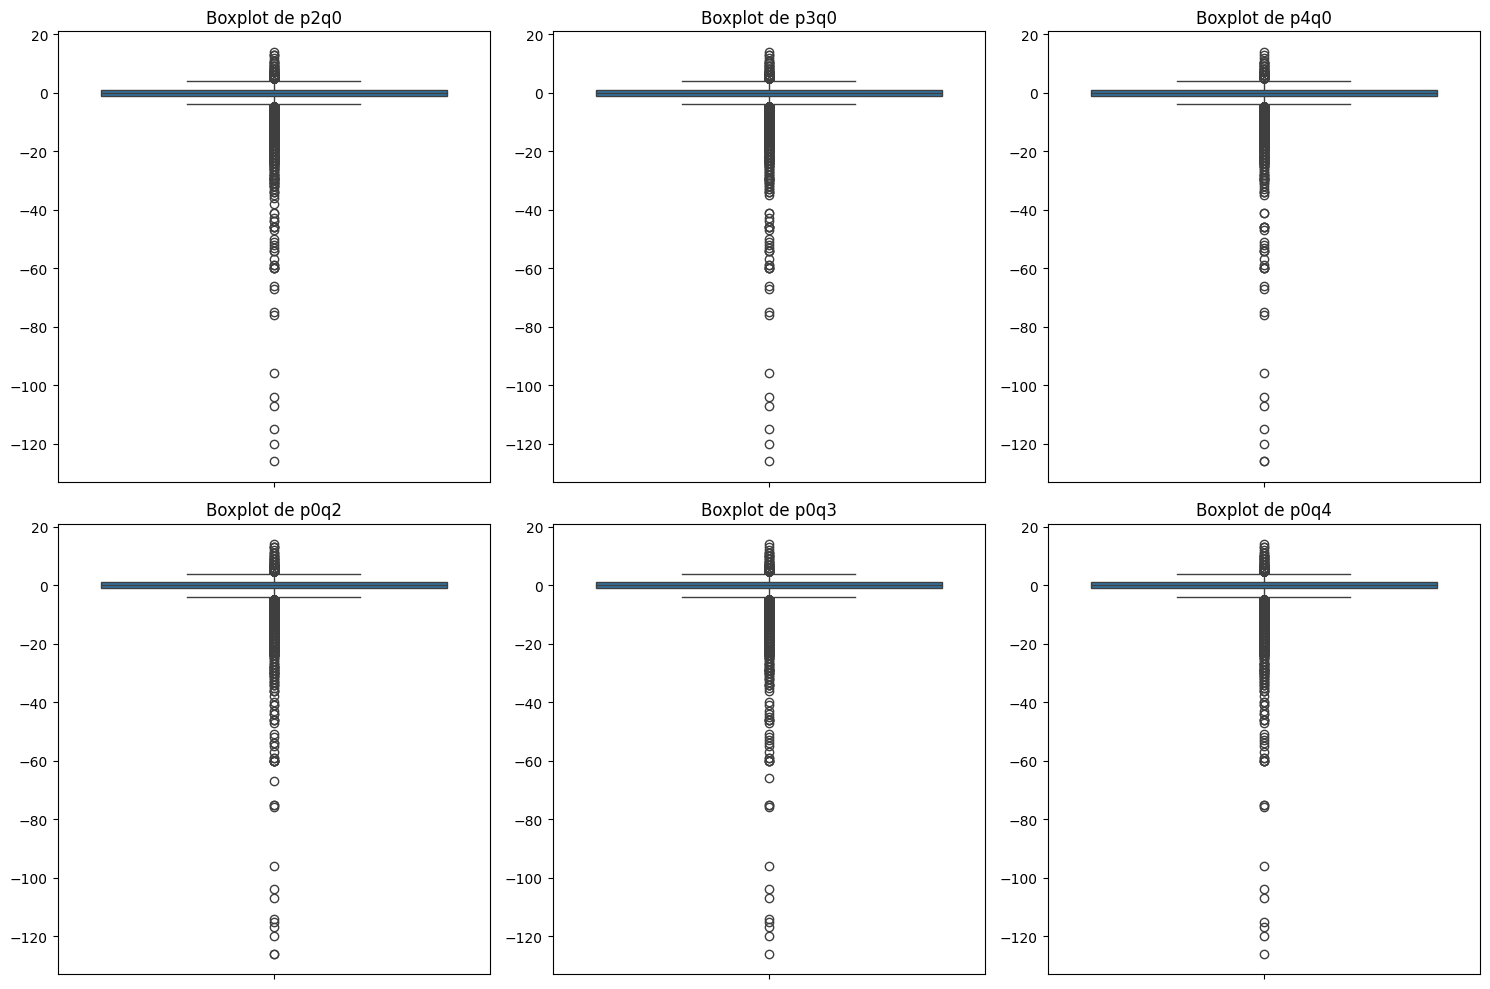

In [59]:
colonnes = ["p2q0","p3q0","p4q0","p0q2","p0q3","p0q4"]


fig, axes = plt.subplots(2, 3, figsize=(15, 10)) 

for ax, col in zip(axes.flatten(), colonnes):
    sns.boxplot(y=month_6[col], ax=ax)
    ax.set_title(f"Boxplot de {col}")
    ax.set_ylabel("") 

plt.tight_layout()
plt.show()

In [47]:
month_5 = X_train_local[X_train_local["month"] == 5]
month_5

,train,gare,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,year,month,day,day_of_week
97485,OQGUKG,KYF,8,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,2023,5,9,1
97486,OQGUKG,JLR,9,1.0,1.0,-1.0,2.0,-1.0,0.0,2023,5,9,1
97487,OQGUKG,EOH,10,-1.0,1.0,1.0,0.0,0.0,2.0,2023,5,9,1
97488,OQGUKG,KCK,11,0.0,-1.0,1.0,-1.0,-1.0,-2.0,2023,5,9,1
97489,OQGUKG,VXY,12,0.0,0.0,-1.0,1.0,-3.0,-3.0,2023,5,9,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
212901,SRCTGZ,DGG,26,0.0,0.0,0.0,1.0,0.0,1.0,2023,5,31,2
212902,SRCTGZ,KDN,27,0.0,0.0,0.0,1.0,0.0,0.0,2023,5,31,2
212903,SRCTGZ,TVD,28,0.0,0.0,0.0,0.0,-1.0,0.0,2023,5,31,2
212904,SRCTGZ,TXP,30,1.0,0.0,0.0,1.0,0.0,0.0,2023,5,31,2


In [61]:
month_5.loc[month_5["p0q3"] <= -500, "p0q3"] = (month_5["p0q2"] + month_5["p0q4"]) / 2
month_5.loc[month_5["p0q4"] <= -500, "p0q4"] = (month_5["p0q2"] + month_5["p0q3"]) / 2

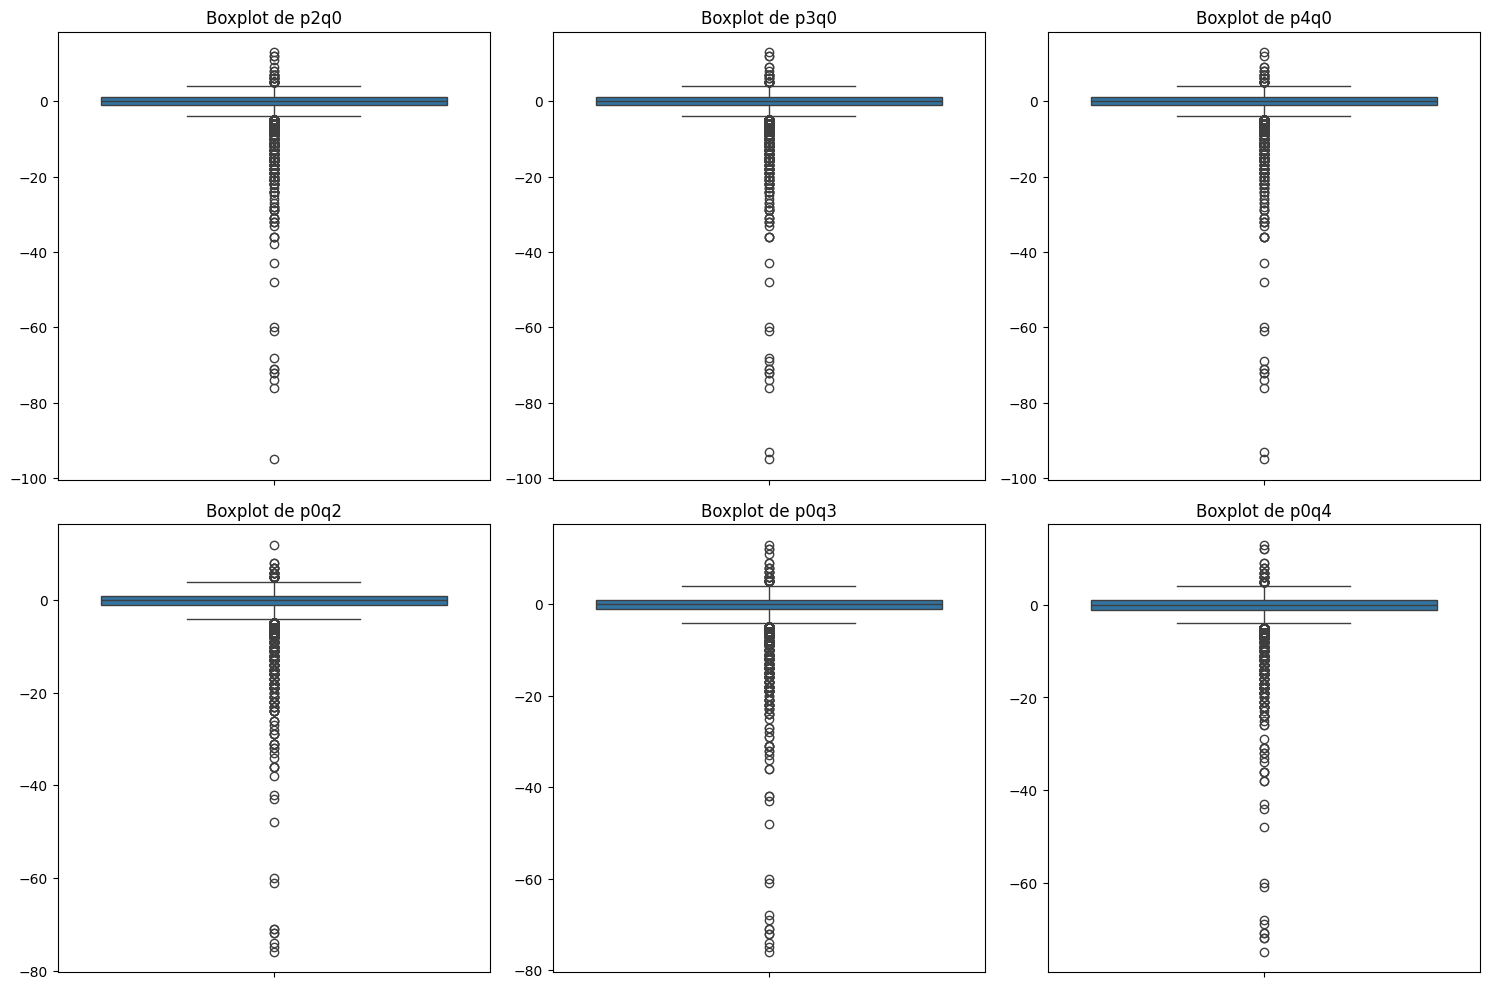

In [62]:
colonnes = ["p2q0","p3q0","p4q0","p0q2","p0q3","p0q4"]


fig, axes = plt.subplots(2, 3, figsize=(15, 10)) 

for ax, col in zip(axes.flatten(), colonnes):
    sns.boxplot(y=month_5[col], ax=ax)
    ax.set_title(f"Boxplot de {col}")
    ax.set_ylabel("") 

plt.tight_layout()
plt.show()

In [48]:
month_5.describe()

,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,year,month,day,day_of_week
count,115421.000000,115421.000000,115421.000000,115421.000000,115421.000000,115421.000000,115421.000000,115421.0,115421.0,115421.000000,115421.000000
mean,18.205396,-0.161912,-0.157406,-0.160387,-0.139654,-0.150960,-0.174622,2023.0,5.0,19.291689,1.958214
std,7.021927,1.613602,1.617806,1.596172,1.600430,1.611585,7.503940,0.0,0.0,7.066568,1.281229
min,7.000000,-95.000000,-95.000000,-95.000000,-76.000000,-76.000000,-1440.000000,2023.0,5.0,9.000000,0.000000
25%,12.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,2023.0,5.0,12.000000,1.000000
50%,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2023.0,5.0,19.000000,2.000000
75%,23.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2023.0,5.0,25.000000,3.000000
max,41.000000,13.000000,13.000000,13.000000,12.000000,13.000000,13.000000,2023.0,5.0,31.000000,4.000000


In [ ]:

X_train_local = X_train_local.drop(columns=['date' , "Unnamed: 0" , "Unnamed: 0.1"])
X_val_local = X_val_local.drop(columns=['date',"Unnamed: 0" , "Unnamed: 0.1"])


In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import numpy as np


categorical_features = ['gare', 'train']

for col in categorical_features:
    X_train_local[col] = X_train_local[col].astype('category')
    X_val_local[col] = X_val_local[col].astype('category')



model = lgb.LGBMRegressor(
    n_estimators=500,       
    learning_rate=0.05,     
    random_state=42,         
    n_jobs=-1                
)

# 3. Entraînement du modèle (uniquement sur les mois 4 à 10 !)
print("Entraînement du modèle en cours...")
model.fit(
    X_train_local, 
    y_train_local,
    categorical_feature=categorical_features
)

# 4. Prédiction sur le jeu de validation (mois 11)
print("Prédiction sur le mois 11...")
preds_brutes = model.predict(X_val_local)


preds_arrondies = np.round(preds_brutes)

mae_brute = mean_absolute_error(y_val_local, preds_brutes)
mae_arrondie = mean_absolute_error(y_val_local, preds_arrondies)

print(f"\n--- RÉSULTATS ---")
print(f"MAE sans arrondi : {mae_brute:.4f} minutes d'erreur en moyenne")
print(f"MAE avec arrondi : {mae_arrondie:.4f} minutes d'erreur en moyenne")

Entraînement du modèle en cours...
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005299 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 30555
[LightGBM] [Info] Number of data points in the train set: 629579, number of used features: 12
[LightGBM] [Info] Start training from score -0.153191
Prédiction sur le mois 11...

--- RÉSULTATS ---
MAE sans arrondi : 0.8219 minutes d'erreur en moyenne
MAE avec arrondi : 0.7674 minutes d'erreur en moyenne


## GroupKFold

In [ ]:
from sklearn.model_selection import GroupKFold

x_train_cpy = x_train.copy()
groupes = x_train_cpy["train"]


gkf = GroupKFold(n_splits=5)

for train_idx, val_idx in gkf.split(X, y, groupes):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

In [64]:
x_train["arret"].unique()

array([ 8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 26,
       24, 25, 28, 29, 27, 30, 33, 34, 37, 32, 31, 36, 40, 35,  7, 38, 41,
       39, 42])

In [65]:
x_test["arret"].unique()

array([12, 18, 24, 30, 36, 17, 13, 19, 21, 25, 20, 26, 34, 31])

In [66]:
for arret in x_test["arret"].unique():
    if arret in x_train["arret"].unique():
        print(arret)

12
18
24
30
36
17
13
19
21
25
20
26
34
31
